# Map of correlations

In [1]:
import xarray as xr
from pathlib import Path

import intake
import matplotlib.pyplot as plt
import easygems.healpix as egh
import cartopy.crs as ccrs

import numpy as np
import pandas as pd

#xr.set_options(display_style="text") # make it look better when posted online. Comment to get nicer representation of xarrays
import os

In [2]:
# define paths
datapath = '/scratch/nf33/Healpix_data/'
model = 'UM'
zoom = 'z2'
fpath = f'{datapath}{model}/data.healpix.PT1H.{zoom}.zarr'

# open the zarr file
ds = xr.open_zarr(fpath)

# what variables are there in the dataset?
for key, longname in ds.data_vars.items():
    print(f'{key}: {longname.long_name}')

clivi: atmosphere_mass_content_of_cloud_ice
clt: cloud_area_fraction
clwvi: atmosphere_mass_content_of_cloud_condensed_water
hflsd: surface_downward_latent_heat_flux
hfssd: surface_downward_sensible_heat_flux
huss: specific_humidity
pr: precipitation_flux
prs: solid_precipitation_flux
prw: atmosphere_mass_content_of_water_vapor
ps: surface_air_pressure
psl: air_pressure_at_mean_sea_level
rlds: surface_downwelling_longwave_flux_in_air
rldscs: surface_downwelling_longwave_flux_in_air_clear_sky
rlut: toa_outgoing_longwave_flux
rlutcs: toa_outgoing_longwave_flux_clear_sky
rsds: surface_downwelling_shortwave_flux_in_air
rsdscs: surface_downwelling_shortwave_flux_in_air_clear_sky
rsdt: toa_incoming_shortwave_flux
rsut: toa_outgoing_shortwave_flux
rsutcs: toa_outgoing_shortwave_flux_clear_sky
tas: air_temperature
ts: surface_temperature
uas: eastward_wind
vas: northward_wind


In [3]:
# define paths
datapath = '/scratch/nf33/Healpix_data/'
model = 'ICON'
zoom = 'z1'
fpath = f'{datapath}{model}/PT1H_inst_{zoom}_atm.zarr'

# open the zarr file
ds = xr.open_zarr(fpath)

# what variables are there in the dataset?
for key, longname in ds.data_vars.items():
    print(f'{key}: {longname.long_name}')

orog: surface altitude
pr: precipitation flux
psl: mean sea level pressure
rlut: toa outgoing longwave radiation
rsut: toa outgoing shortwave radiation
sftgif: cell area fraction occupied by land ice
sftlf: cell area fraction occupied by land including lakes
ts: surface temperature
uas: zonal wind in 10m
vas: meridional wind in 10m


In [4]:
# read UM z2
ds_2 = xr.open_zarr(fpath)
ds_2

<xarray.Dataset> Size: 14MB
Dimensions:  (crs: 1, cell: 48, time: 10200)
Coordinates:
  * crs      (crs) float32 4B nan
  * time     (time) datetime64[ns] 82kB 2020-01-01T01:00:00 ... 2021-03-01
Dimensions without coordinates: cell
Data variables:
    orog     (cell) float32 192B dask.array<chunksize=(48,), meta=np.ndarray>
    pr       (time, cell) float32 2MB dask.array<chunksize=(4, 48), meta=np.ndarray>
    psl      (time, cell) float32 2MB dask.array<chunksize=(4, 48), meta=np.ndarray>
    rlut     (time, cell) float32 2MB dask.array<chunksize=(4, 48), meta=np.ndarray>
    rsut     (time, cell) float32 2MB dask.array<chunksize=(4, 48), meta=np.ndarray>
    sftgif   (cell) float32 192B dask.array<chunksize=(48,), meta=np.ndarray>
    sftlf    (cell) float32 192B dask.array<chunksize=(48,), meta=np.ndarray>
    ts       (time, cell) float32 2MB dask.array<chunksize=(4, 48), meta=np.ndarray>
    uas      (time, cell) float32 2MB dask.array<chunksize=(4, 48), meta=np.ndarray>
    vas      (time, cell) float32 2MB dask.array<chunksize=(4, 48), meta=np.ndarray>
Attributes:
    hiopy::parent:  PT1H_point_z2_atm

In [5]:
ds_2.pr

<xarray.DataArray 'pr' (time: 10200, cell: 48)> Size: 2MB
dask.array<open_dataset-pr, shape=(10200, 48), dtype=float32, chunksize=(4, 48), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 82kB 2020-01-01T01:00:00 ... 2021-03-01
Dimensions without coordinates: cell
Attributes:
    grid_mapping:        crs
    hiopy::time_method:  point
    hiopy::nnn:          4
    hiopy::enable:       True
    standard_name:       pr
    units:               kg m-2 s-1
    short_name:          
    long_name:           precipitation flux

In [6]:
ds_2.time

<xarray.DataArray 'time' (time: 10200)> Size: 82kB
array(['2020-01-01T01:00:00.000000000', '2020-01-01T02:00:00.000000000',
       '2020-01-01T03:00:00.000000000', ..., '2021-02-28T22:00:00.000000000',
       '2021-02-28T23:00:00.000000000', '2021-03-01T00:00:00.000000000'],
      shape=(10200,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 82kB 2020-01-01T01:00:00 ... 2021-03-01
Attributes:
    axis:     T

In [7]:
ds_2.pr.mean("cell").values[:40]

array([9.9054341e-06, 1.5905764e-05, 2.0837708e-05, 2.5206818e-05,
       2.8552944e-05, 3.1004700e-05, 3.2434153e-05, 3.3023480e-05,
       3.3359549e-05, 3.4277455e-05, 3.5615838e-05, 3.5845991e-05,
       3.5568130e-05, 3.5420380e-05, 3.5863002e-05, 3.6761601e-05,
       3.7033602e-05, 3.6655525e-05, 3.5824585e-05, 3.5024223e-05,
       3.3652610e-05, 3.2434702e-05, 3.1345709e-05, 3.0770385e-05,
       3.0570558e-05, 3.0473157e-05, 3.0552877e-05, 3.0904321e-05,
       3.1377036e-05, 3.1645108e-05, 3.1631953e-05, 3.1599655e-05,
       3.1601056e-05, 3.2179687e-05, 3.3075317e-05, 3.3574815e-05,
       3.3947865e-05, 3.4330467e-05, 3.5305642e-05, 3.5919464e-05],
      dtype=float32)

/scratch/nf33/public/miniconda/envs/digital_earths_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/scratch/nf33/public/miniconda/envs/digital_earths_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/scratch/nf33/public/miniconda/envs/digital_earths_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/scratch/nf33/public/miniconda/envs/digital_earths_env/lib/python3.12/site-packages/dask/_task_spec.py:758: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/scratch/nf33/public/miniconda/envs/digital_earths_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/scratch/nf33/public/mi

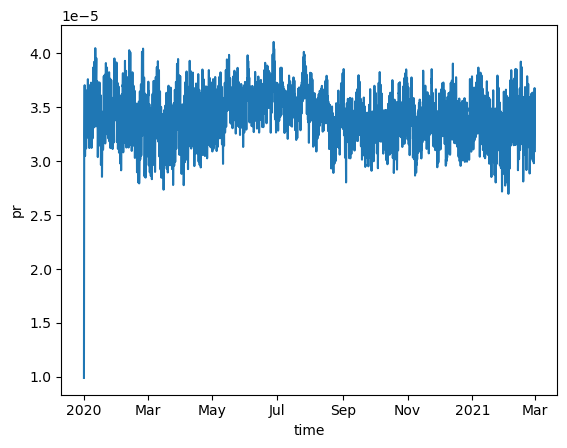

In [8]:
ds_2.pr.mean("cell").plot()

In [9]:
data = ds_2.pr.isel(time=20)

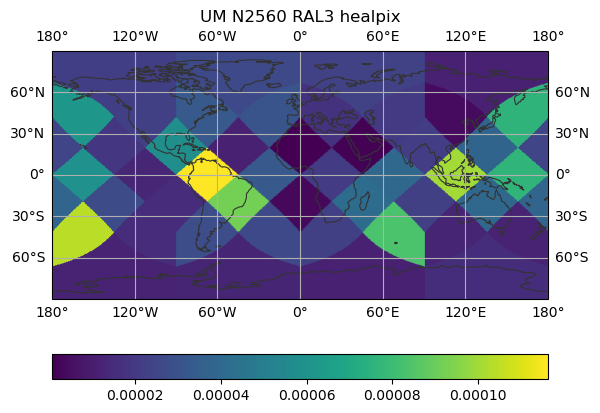

In [10]:
# Plotting lat/lon values over the grid
projection=ccrs.PlateCarree(central_longitude=0.0)

ax = egh.create_geoaxis(add_coastlines=True,projection=projection)
im = egh.healpix_show(data.values, ax=ax, add_coastlines=True)
ax.set_title(f'UM N2560 RAL3 healpix')
ax.gridlines(draw_labels=True)
fig=ax.get_figure()
fig.colorbar(im,orientation='horizontal')

In [11]:
datapath = '/g/data/qx55/germany_node/d3hp003.zarr'
file = 'P1D'
zoom = 'z5'

# define the fname
fpath = f'{datapath}/{file}_mean_{zoom}_atm.zarr'

# open the zarr file
ds = xr.open_zarr(fpath)

# what variables are there in the dataset?
for key, longname in ds.data_vars.items():
    print(f'{key}: {longname.long_name}')


clivi: cloud ice path
clt: total cloud cover
clwvi: cloud condensed water path
egpvi: Atmosphere Geopotential Energy Content
einvi: Atmosphere Moist Internal Energy Content
ekhvi: Atmosphere Horizontal Kinetic Energy Content
ekvvi: Atmosphere Vertical Kinetic Energy Content
hflsd: latent heat flux
hfssd: sensible heat flux
hur: relative humidity
hus: Specific humidity
huss: specific humidity in 2m
mrso: Water content of soil layers
o3vi: ozone path
orog: surface altitude
pr: precipitation flux
prs: large-scale precipitation flux (snow)
prw: water vapor path
ps: surface pressure
psl: mean sea level pressure
qall: mass fraction of all hydrometeors in air
rlds: surface downwelling longwave radiation
rldscs: surface downwelling clear-sky longwave radiation
rlus: surface upwelling longwave radiation
rlut: toa outgoing longwave radiation
rlutcs: toa outgoing clear-sky longwave radiation
rsds: surface downwelling shortwave radiation
rsdscs: surface downwelling clear-sky shortwave radiation
rs

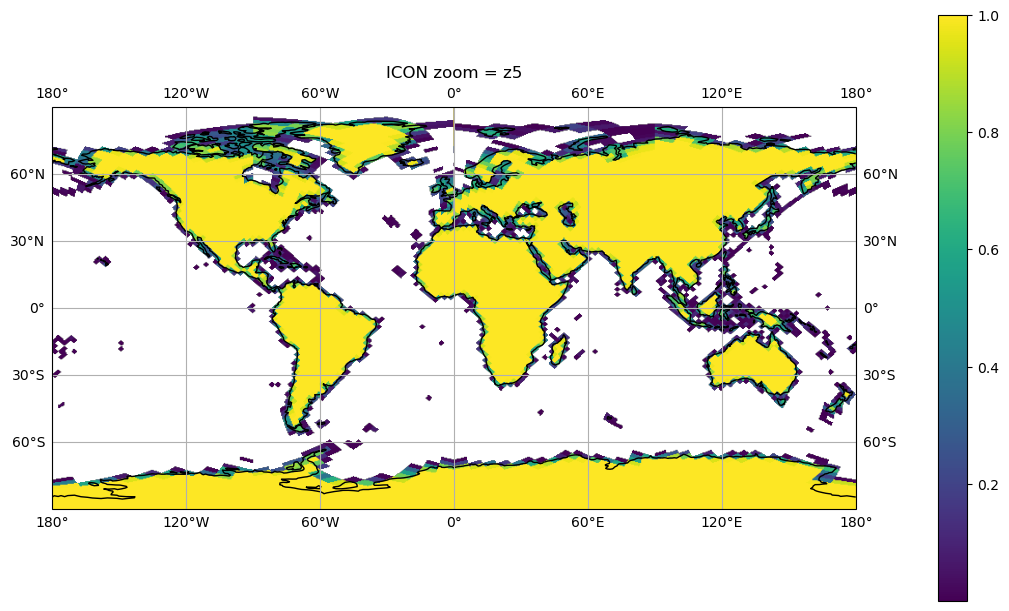

In [12]:
# choose a variable to plot
da = ds['sftlf']

# test plot some data
plt.close('all')
projection=ccrs.PlateCarree(central_longitude=0.0)
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection}, layout='constrained')

data = da
ax.set_global()
im = egh.healpix_show(data.values,ax=ax)
ax.set_title(f'ICON zoom = {zoom}')
ax.coastlines()
ax.gridlines(draw_labels=True)
fig.colorbar(im,orientation='vertical')

plt.show()

In [13]:
#calculate evapotranspiration 
evapo = ds['hflsd']*-1/(2.501*1000000); Pre = ds['pr'] * 86400

In [14]:
evapo

<xarray.DataArray 'hflsd' (time: 425, cell: 12288)> Size: 21MB
dask.array<truediv, shape=(425, 12288), dtype=float32, chunksize=(4, 12288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-02 2020-01-03 ... 2021-03-01
Dimensions without coordinates: cell

In [15]:
ds_jja = ds.sel(time=ds['time'].dt.month.isin([6, 7, 8]))

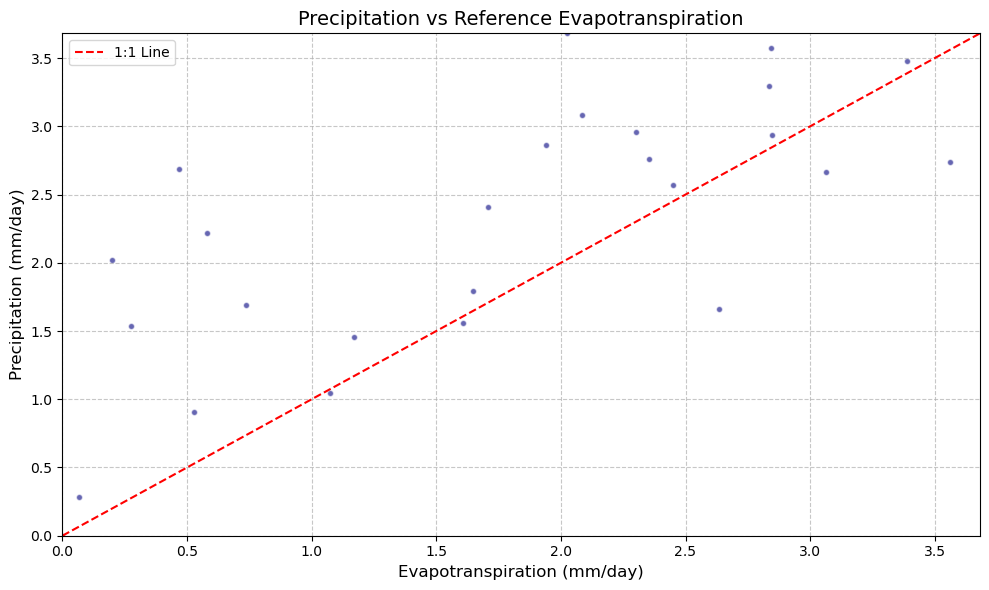

In [16]:
import matplotlib.pyplot as plt
# Calculate evapotranspiration and precipitation [[1]][[6]]
evapo = ds_jja.hflsd.mean("cell")*-1/ (2.501 * 10**6)  # Convert W/m² to mm/day using latent heat of vaporization
Pre = ds_jja.pr.mean("cell")* 86400  # Convert kg/m²/s to mm/day (1 kg/m² = 1 mm)

# Calculate min and max for Pre and evapo
pre_min = Pre.min().values
pre_max = Pre.max().values
evapo_min = evapo.min().values
evapo_max = evapo.max().values

# Normalize to [0, 6] using min-max scaling [[1]][[7]]
Pre_normalized = (Pre - pre_min) / (pre_max - pre_min) * 8
evapo_normalized = (evapo - evapo_min) / (evapo_max - evapo_min) * 6

# Create scatter plot [[3]][[7]]
plt.figure(figsize=(10, 6))
plt.scatter(evapo_normalized, Pre_normalized, alpha=0.6, c='navy', edgecolors='w', s=20)
#plt.plot(evapo_normalized, Pre_normalized, label='Precipitation', color='navy')

# Add labels and title
plt.xlabel('Evapotranspiration (mm/day)', fontsize=12)
plt.ylabel('Precipitation (mm/day)', fontsize=12)
plt.title('Precipitation vs Reference Evapotranspiration', fontsize=14)

# Add grid and 1:1 line for reference
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot([0, 10], [0, 10], 'r--', label='1:1 Line')

# Set axis limits based on data range
plt.xlim(0, max(evapo.max(), Pre.max())*1.1)
plt.ylim(0, max(evapo.max(), Pre.max())*1.1)

plt.legend()
plt.tight_layout()
plt.show()

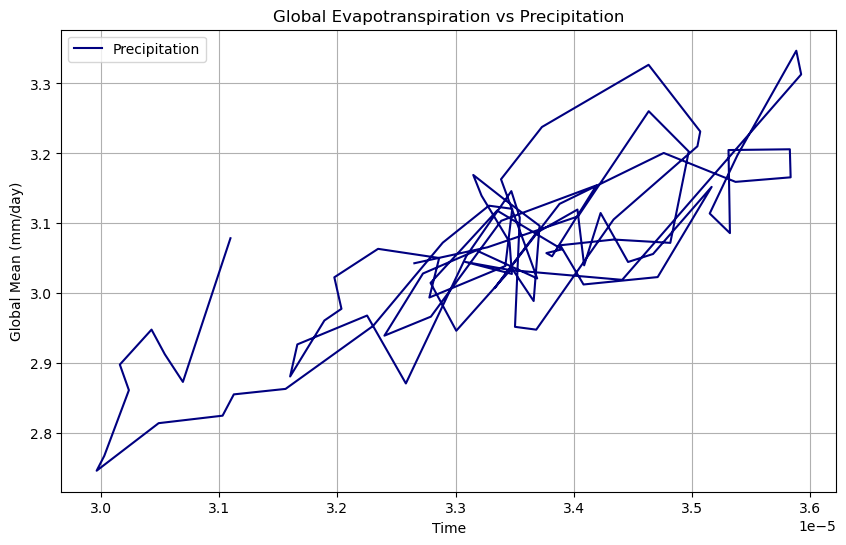

In [17]:
plt.figure(figsize=(10, 6))
#plt.scatter(evapo.time, evapo, label='Evapotranspiration', color='blue')
plt.plot(evapo, Pre, label='Precipitation', color='navy')
plt.xlabel('Time')
plt.ylabel('Global Mean (mm/day)')
plt.title('Global Evapotranspiration vs Precipitation')
plt.legend()
plt.grid(True)
plt.show()

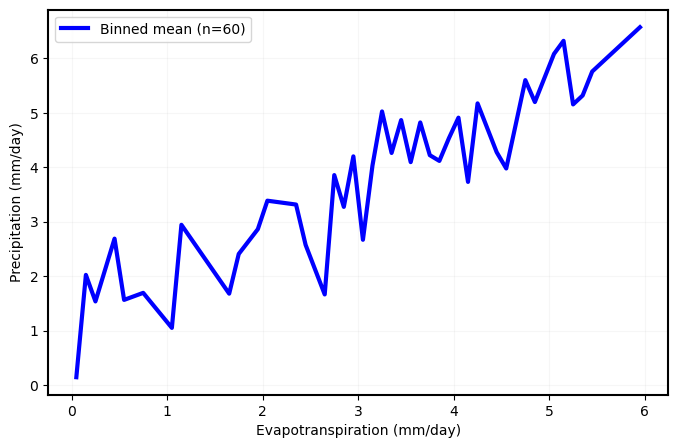

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# assume evapo_n, Pre_n are your normalized 1D arrays
x = evapo_normalized.values.flatten()
y = Pre_normalized.values.flatten()

# 1) choose number of bins
nbins = 60
bins = np.linspace(x.min(), x.max(), nbins+1)

# 2) digitize and compute mean y per bin
inds = np.digitize(x, bins)
x_centers = (bins[:-1] + bins[1:]) / 2.0
y_means = np.array([y[inds == i].mean() if np.any(inds == i) else np.nan
                    for i in range(1, len(bins))])

# 3) mask empty bins and plot
valid = ~np.isnan(y_means)
plt.figure(figsize=(8,5))
#plt.scatter(x, y, alpha=0.3, s=10, c='navy', edgecolor='none')
plt.plot(x_centers[valid], y_means[valid],
         c='blue', linewidth=3, label='Binned mean (n={})'.format(nbins))

plt.xlabel('Evapotranspiration (mm/day)')
plt.ylabel('Precipitation (mm/day)')
plt.legend()
plt.grid(alpha=0.1)
plt.show()


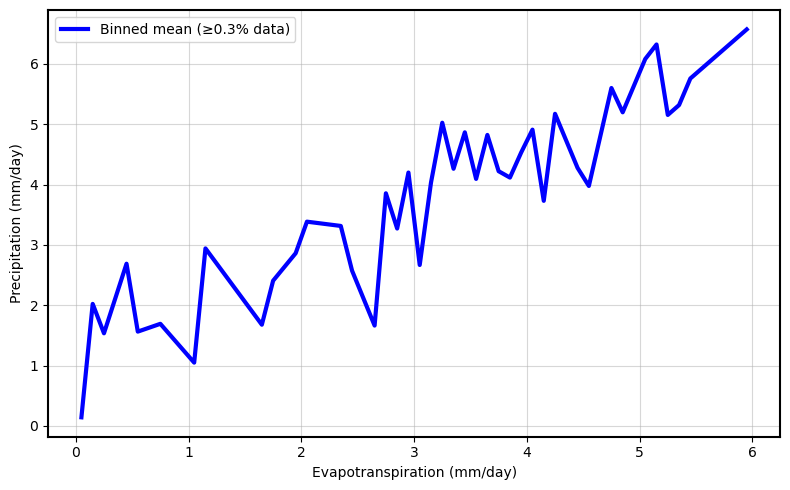

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten input arrays
x = evapo_normalized.values.flatten()
y = Pre_normalized.values.flatten()
N = len(x)
threshold = 0.003 * N  # 0.3% of total points

# Define bins and assign x to bins
nbins = 60
bins = np.linspace(x.min(), x.max(), nbins+1)
inds = np.digitize(x, bins)
x_centers = (bins[:-1] + bins[1:]) / 2.0

# Compute mean y for each bin and apply threshold
y_means = []
for i in range(1, len(bins)):
    bin_members = y[inds == i]
    if len(bin_members) >= threshold:
        y_means.append(bin_members.mean())
    else:
        y_means.append(np.nan)

y_means = np.array(y_means)
valid = ~np.isnan(y_means)

# Plot
plt.figure(figsize=(8, 5))
#plt.scatter(x, y, alpha=0.3, s=10, c='navy', edgecolor='none', label='Raw data')
plt.plot(x_centers[valid], y_means[valid], c='blue', linewidth=3, label='Binned mean (≥0.3% data)')

plt.xlabel('Evapotranspiration (mm/day)')
plt.ylabel('Precipitation (mm/day)')
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()


In [18]:
Pre

<xarray.DataArray 'pr' (time: 92)> Size: 368B
dask.array<mul, shape=(92,), dtype=float32, chunksize=(3,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 736B 2020-06-01 2020-06-02 ... 2020-08-31

In [19]:
ds['pr']

<xarray.DataArray 'pr' (time: 425, cell: 12288)> Size: 21MB
dask.array<open_dataset-pr, shape=(425, 12288), dtype=float32, chunksize=(4, 12288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-02 2020-01-03 ... 2021-03-01
Dimensions without coordinates: cell
Attributes:
    grid_mapping:        crs
    hiopy::time_method:  mean
    hiopy::nnn:          4
    hiopy::enable:       True
    standard_name:       pr
    units:               kg m-2 s-1
    short_name:          
    long_name:           precipitation flux

In [20]:
icon_pr = ds['pr'].mean('time')* 86400

In [21]:
icon_pr = ds['pr'].mean('time')* 86400
icon_smi = xr.where( (icon_pr>=.1)&(ds['sftlf']>0.1), ds['mrso'], np.nan)
icon_y1  = xr.where( (icon_pr>=.1)&(ds['sftlf']>0.1), ds['hflsd']*-1, np.nan)
icon_y2  = xr.where( (icon_pr>=.1)&(ds['sftlf']>0.1), ds['hfssd'], np.nan)

icon_corr_lh_pr      = xr.where((icon_pr>=.1)&( ds['sftlf'] >0.1), 
                                xr.corr(ds['pr'], icon_y1, dim='time'), np.nan) #.values
icon_corr_sh_pr      = xr.where((icon_pr>=.1)&( ds['sftlf'] >0.1), 
                                xr.corr(ds['pr'], icon_y2, dim='time'), np.nan) #.values

In [22]:
icon_corr_lh_pr.values

array([-0.0035022 , -0.09791002,  0.36228088, ...,  0.08003114,
        0.4601885 , -0.18052296], shape=(12288,), dtype=float32)

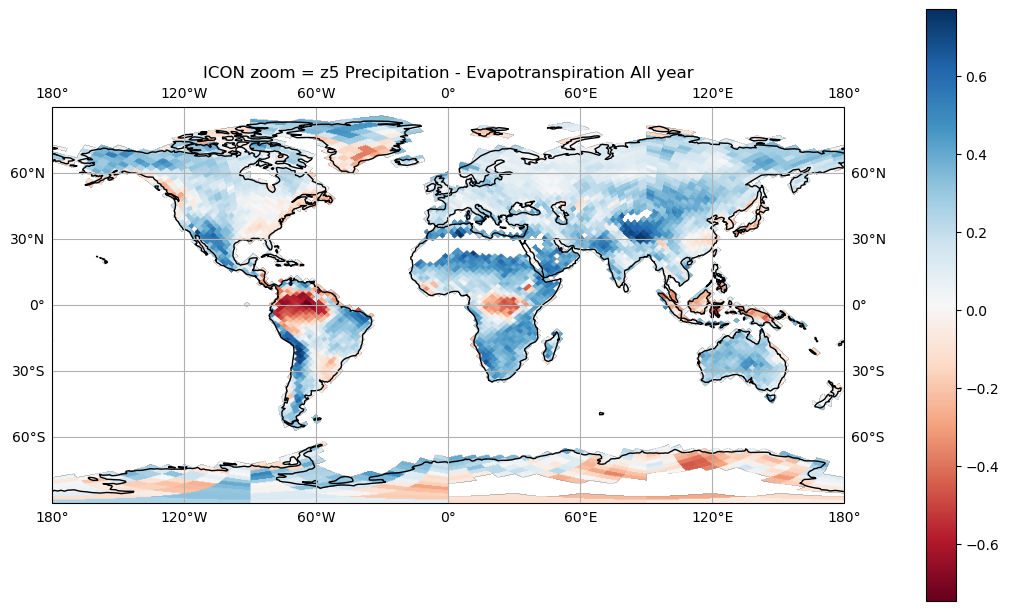

In [23]:
plt.close('all')
projection=ccrs.PlateCarree(central_longitude=0.0)
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection}, layout='constrained')

#data = da.isel(time=20, soil_level=1)

ax.set_global()
im = egh.healpix_show(icon_corr_lh_pr.values,ax=ax,cmap='RdBu')
ax.set_title(f'ICON zoom = {zoom} Precipitation - Evapotranspiration All year')
ax.coastlines()
ax.gridlines(draw_labels=True)
fig.colorbar(im,orientation='vertical')

plt.show()

In [24]:
ds_jja = ds.sel(time=ds['time'].dt.month.isin([6, 7, 8]))

In [25]:
ds_jja = ds.sel(time=ds['time'].dt.month.isin([6, 7, 8]))

In [26]:
ds_jja['mrso']

<xarray.DataArray 'mrso' (time: 92, soil_level: 5, cell: 12288)> Size: 23MB
dask.array<getitem, shape=(92, 5, 12288), dtype=float32, chunksize=(3, 1, 12288), chunktype=numpy.ndarray>
Coordinates:
  * soil_level  (soil_level) int64 40B 0 0 0 2 6
  * time        (time) datetime64[ns] 736B 2020-06-01 2020-06-02 ... 2020-08-31
Dimensions without coordinates: cell
Attributes:
    grid_mapping:        crs
    hiopy::time_method:  mean
    hiopy::nnn:          4
    hiopy::enable:       True
    standard_name:       wtr_soil_sl
    units:               m
    short_name:          
    long_name:           Water content of soil layers

In [27]:
icon_smi = xr.where( (icon_pr>=.1)&(ds['sftlf']>0.9), ds_jja['mrso'].isel(soil_level=0), np.nan)
icon_y1  = xr.where( (icon_pr>=.1)&(ds['sftlf']>0.9), ds_jja['hflsd'], np.nan)
icon_y2  = xr.where( (icon_pr>=.1)&(ds['sftlf']>0.9), ds_jja['hfssd'], np.nan)

icon_corr_lh_pr      = xr.where((icon_pr>=.1)&( ds['sftlf'] >0.9), 
                                xr.corr(ds_jja['pr'], icon_y1, dim='time'), np.nan) #.values
icon_corr_sh_pr      = xr.where((icon_pr>=.1)&( ds['sftlf'] >0.9), 
                                xr.corr(ds_jja['pr'], icon_y2, dim='time'), np.nan) #.values
icon_corr_sm_pr      = xr.where((icon_pr>=.1)&( ds['sftlf'] >0.9), 
                                xr.corr(ds_jja['pr'], icon_smi, dim='time'), np.nan) #.values

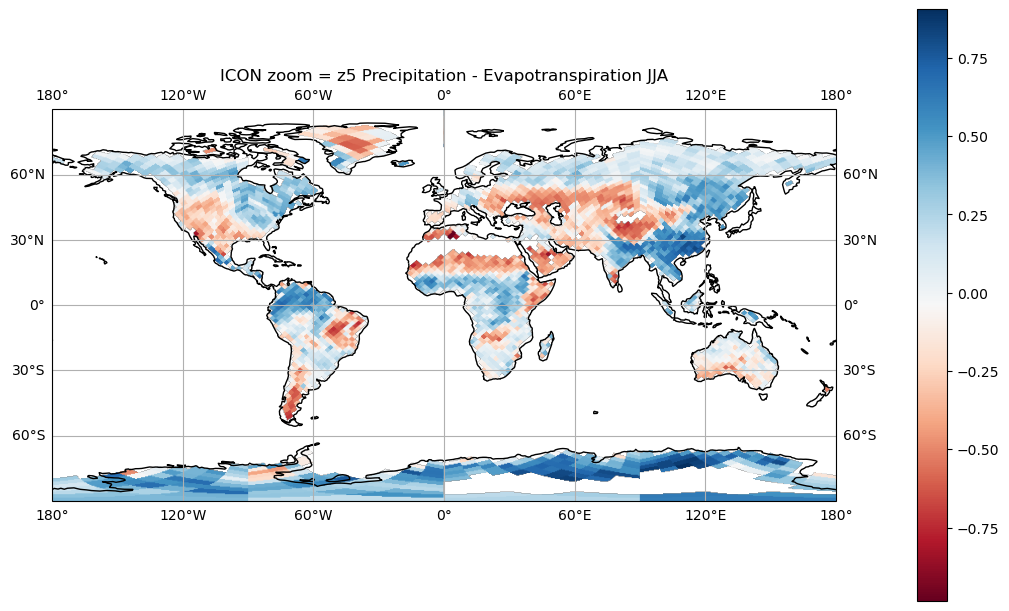

In [28]:
plt.close('all')
projection=ccrs.PlateCarree(central_longitude=0.0)
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection}, layout='constrained')

#data = da.isel(time=20, soil_level=1)

ax.set_global()
im = egh.healpix_show(icon_corr_lh_pr.values,ax=ax,cmap='RdBu')
ax.set_title(f'ICON zoom = {zoom} Precipitation - Evapotranspiration JJA')
ax.coastlines()
ax.gridlines(draw_labels=True)
fig.colorbar(im,orientation='vertical')

plt.show()

In [29]:
icon_corr_sm_pr.values

array([      nan,       nan, 0.6134639, ...,       nan, 0.6569021,
             nan], shape=(12288,), dtype=float32)

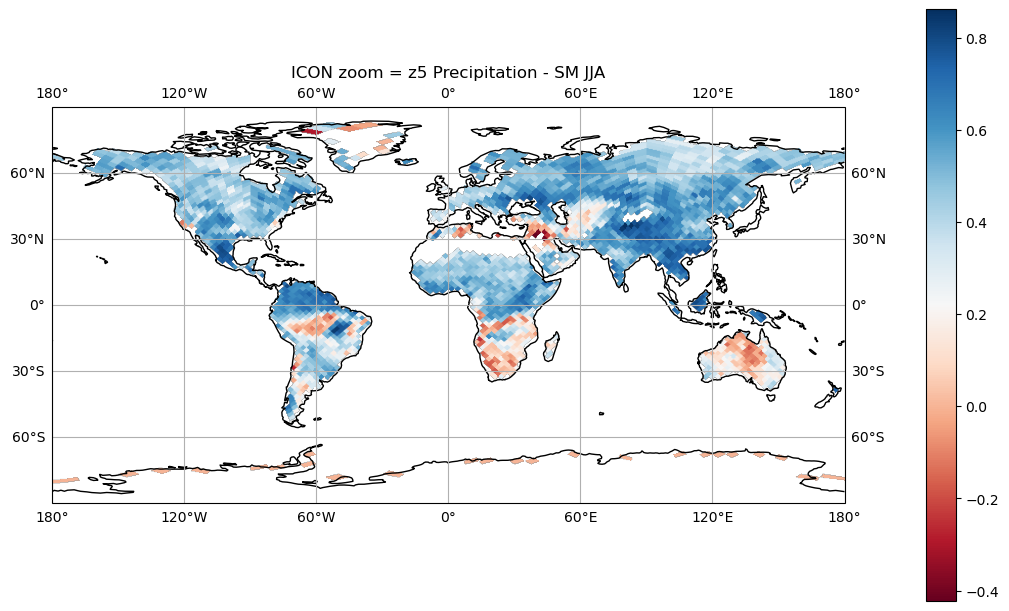

In [30]:
plt.close('all')
projection=ccrs.PlateCarree(central_longitude=0.0)
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection}, layout='constrained')

#data = da.isel(time=20, soil_level=1)

ax.set_global()
im = egh.healpix_show(icon_corr_sm_pr.values,ax=ax,cmap='RdBu')
ax.set_title(f'ICON zoom = {zoom} Precipitation - SM JJA')
ax.coastlines()
ax.gridlines(draw_labels=True)
fig.colorbar(im,orientation='vertical')

plt.show()

In [31]:
# double check of correlations

icon_smi = xr.where( (icon_pr>=.1)&(ds['sftlf']>0.1), ds['mrso'], np.nan)
icon_y1  = xr.where( (icon_pr>=.1)&(ds['sftlf']>0.1), ds['hflsd'], np.nan)
#icon_y2  = xr.where( (icon_pr>=.1)&(ds['sftlf']<0.1), ds['hfssd'], np.nan)

icon_corr_lh_pr      = xr.where((icon_pr>=.1)&( ds['sftlf'] >0.1), 
                                xr.corr(ds['pr'], icon_y1, dim='time'), np.nan) #.values
icon_corr_smi_pr      = xr.where((icon_pr>=.1)&( ds['sftlf'] >0.1), 
                                xr.corr(ds['pr'], icon_smi, dim='time'), np.nan) #.values
icon_corr_lh_smi      = xr.where((icon_pr>=.1)&( ds['sftlf'] >0.1), 
                                xr.corr(icon_y1, icon_smi, dim='time'), np.nan) #.values



In [32]:
icon_corr_lh_pr.values

array([ 0.0035022 ,  0.09791002, -0.36228088, ..., -0.08003114,
       -0.4601885 ,  0.18052296], shape=(12288,), dtype=float32)

In [33]:
 icon_smi.mean('time').values

array([[0.01107431, 0.04293049, 0.05636216, 0.06101168, 0.        ],
       [0.01198344, 0.04671318, 0.07348981, 0.09963602, 0.        ],
       [0.01263694, 0.04927346, 0.11232862, 0.2689379 , 0.        ],
       ...,
       [0.01382968, 0.05211689, 0.11073898, 0.09909102, 0.        ],
       [0.01959469, 0.07248779, 0.22734906, 0.06475818, 0.        ],
       [0.01288039, 0.0491474 , 0.09471906, 0.1616224 , 0.00120524]],
      shape=(12288, 5), dtype=float32)

In [34]:
 icon_smi1 =  icon_smi.isel(soil_level=0)

In [35]:
 icon_smi1.mean('time').values

array([0.01107431, 0.01198344, 0.01263694, ..., 0.01382968, 0.01959469,
       0.01288039], shape=(12288,), dtype=float32)

In [36]:
internal_pr_smi = xr.concat(icon_corr_smi_pr,dim='time')
#internal_pr_smi['time'] =  pd.date_range('2000-06-01', periods=90, freq='1Y')

internal_lh_pr = xr.concat(icon_corr_lh_pr,dim='time')
#internal_lh_pr['time'] =  pd.date_range('2000-06-01', periods=90, freq='1Y')

In [37]:
def bin_ave_2d(x_dat_in, y_dat_in, x_bin_in):
    '''
    '''
    x_dat,y_dat = x_dat_in.flatten(),y_dat_in.flatten()
    x_dim,y_dim = len(x_dat),len(y_dat)
    x_bin_dim = len(x_bin_in)

    z,zn,z_std = np.zeros((x_bin_dim-1)),np.zeros((x_bin_dim-1)),np.zeros((x_bin_dim-1))

    for xx in np.arange(x_bin_dim-1):
        var = []
        for ii in np.arange(x_dim):
            if (x_dat[ii]>=x_bin_in[xx]) & (x_dat[ii]<x_bin_in[xx+1]) & (~np.isnan(y_dat[ii])):
                var.append(y_dat[ii])
                z[xx] = z[xx] + y_dat[ii]
                zn[xx] = zn[xx] + 1
        z[xx] = np.nanmean(np.array(var))
        z_std[xx] = np.nanstd(np.array(var))

    y_out = z  #/zn
    x_out = (x_bin_in[:-1]+x_bin_in[1:])/2.
    
    return x_out, y_out, z_std, zn

In [38]:
#apply second condition with SD to mask grid cells
# Fig. a
xmina, xmaxa, dxa = -1, 2, 0.1
xdata1, ydata1 = icon_smi1.mean('time').values, icon_corr_lh_smi.values
x_outa1, y_outa1, z_outa1, zna1 = bin_ave_2d(xdata1, ydata1, np.arange(xmina,xmaxa+dxa,dxa))

xminc, xmaxc, dxc = -1, 2, 0.1
xdatc1, ydatc1 = icon_smi1.mean('time').values, icon_corr_lh_pr.values
x_outc1, y_outc1, z_outc1, znc1 = bin_ave_2d(xdatc1, ydatc1, np.arange(xminc,xmaxc+dxc,dxc))



/jobfs/140914124.gadi-pbs/ipykernel_1233526/1154828569.py:17: RuntimeWarning: Mean of empty slice
  z[xx] = np.nanmean(np.array(var))
/scratch/nf33/public/miniconda/envs/digital_earths_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/jobfs/140914124.gadi-pbs/ipykernel_1233526/1154828569.py:17: RuntimeWarning: Mean of empty slice
  z[xx] = np.nanmean(np.array(var))
/scratch/nf33/public/miniconda/envs/digital_earths_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [39]:
icon_pr = ds['pr'].mean('time')* 86400
icon_P = xr.where( (icon_pr>=.1)&(ds['sftlf']>0.1), ds['pr'], np.nan)


In [40]:
icon_P

<xarray.DataArray (cell: 12288, time: 425)> Size: 21MB
dask.array<where, shape=(12288, 425), dtype=float32, chunksize=(12288, 4), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-02 2020-01-03 ... 2021-03-01
Dimensions without coordinates: cell

In [41]:

# Fig. c

# Fig. b
from scipy.stats import binned_statistic
xmin, xmax, dx = -1, 20, 0.1

xdatb1, ydatb1 = icon_y1.values.flatten()*86400./2.5008e6, icon_P.values.flatten()


xx_1 = xdatb1.flatten()
yy_1 = ydatb1.flatten()
yy_2 = yy_1[~np.isnan(xx_1)]
xx_2 = xx_1[~np.isnan(xx_1)]
xx = xx_2[~np.isnan(yy_2)]
yy = yy_2[~np.isnan(yy_2)]

bin_means = binned_statistic(xx, yy, bins=np.arange(xmin, xmax+dx, dx), range=(xmin, xmax))
bin_stds  = binned_statistic(xx, yy, statistic='std', bins=np.arange(xmin, xmax+dx, dx), range=(xmin, xmax))
x_outb1 = np.diff(bin_means[1])/2.+bin_means[1][:-1]
y_outb1 = bin_means[0]
zn_bin1= bin_means[1]
znb1    = bin_means[2]
std_outb1 = bin_stds[0]


Text(0.0, 1.05, '(a)')

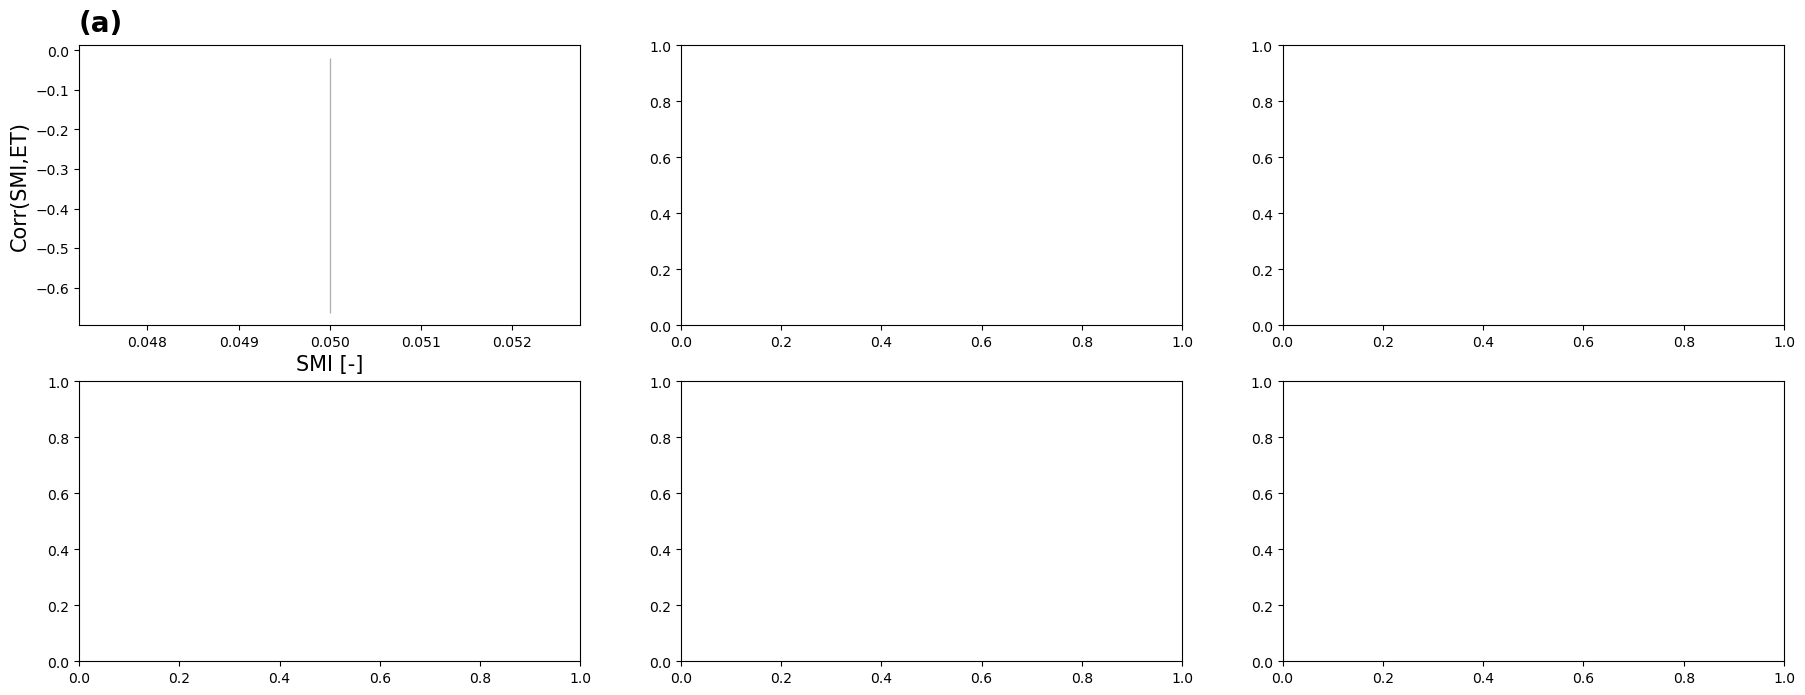

In [42]:
txt_x, txt_y = 0.0, 1.05

rmax, cmax = 2, 3
fig, ax = plt.subplots(nrows=rmax,ncols=cmax, figsize=(22,8),)

## Fig. a
rr, cc = 0, 0
y_outa1 = np.where(zna1>=np.sum(zna1) * 0.01, y_outa1, np.nan)
x_outa1 = np.where(zna1>=np.sum(zna1) * 0.01, x_outa1, np.nan)
z_outa1 = np.where(zna1>=np.sum(zna1) * 0.01, z_outa1, np.nan)
ax[rr,cc].plot(x_outa1, y_outa1, c='k',                 linewidth=5.4)
ax[rr,cc].plot(x_outa1, y_outa1, c=plt.cm.RdBu([0.85]), linewidth=5)
ax[rr,cc].fill_between(x_outa1, y_outa1-z_outa1, y_outa1+z_outa1 ,alpha=0.3, color='C0', edgecolor='k')
#ax[rr,cc].set_xlim(-0.2, 1.7)
#ax[rr,cc].set_ylim(-1.5, 1)
#ax[rr,cc].set_yticks(np.arange(-0.25,1.0+0.25,0.25))
ax[rr,cc].set_xlabel('SMI [-]', fontsize=15)
ax[rr,cc].set_ylabel('Corr(SMI,ET)', fontsize=15)
#ax[rr,cc].yaxis.set_label_coords(-0.10,0.75)
ax[rr,cc].text(txt_x, txt_y, '(a)', transform=ax[rr,cc].transAxes, size=20, weight='bold')


In [43]:
## Fig. b
rr, cc = 0, 1
y_outc1 = np.where(znc1>=np.sum(znc1) * 0.01, y_outc1, np.nan)
x_outc1 = np.where(znc1>=np.sum(znc1) * 0.01, x_outc1, np.nan)
z_outc1 = np.where(znc1>=np.sum(znc1) * 0.01, z_outc1, np.nan)
ax[rr,cc].plot(x_outc1, y_outc1, c='k',                 linewidth=5.4)
ax[rr,cc].plot(x_outc1, y_outc1, c=plt.cm.RdBu([0.85]), linewidth=5)
ax[rr,cc].set_xlim(-0.2, 1.7)
ax[rr,cc].set_ylim(-0.75, 0.75)
ax[rr,cc].set_yticks(np.arange(-0.75,0.75+0.25,0.25))
ax[rr,cc].set_xlabel('SMI [-]', fontsize=15)
ax[rr,cc].set_ylabel('Correlation', fontsize=15)
ax[rr,cc].text(txt_x, txt_y, '(b)', transform=ax[rr,cc].transAxes, size=20, weight='bold')


Text(0.0, 1.05, '(b)')

In [44]:
from scipy import stats
import matplotlib
#%matplotlib inline
import matplotlib as mpl
import matplotlib.pylab as plt
import matplotlib.tri as mtri
import matplotlib.dates as md
import matplotlib.patches as patches
import matplotlib.dates as mdates
import matplotlib.cbook as cbook
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
## Fig. c
rr, cc = 1, 0
bin_len = np.arange(xmin, xmax+dx, dx).shape[0]
yval, xval = np.histogram(znb1, bins=np.arange(bin_len))
xval = np.diff(xval)/2.+xval[:-1]

x_msk1 = np.where(yval>=np.sum(yval) * 0.003, x_outb1, np.nan )
ax[rr,cc].plot(x_msk1, y_outb1, c='k',linewidth=5.4)
ax[rr,cc].plot(x_msk1, y_outb1, c=plt.cm.RdBu([0.85]),linewidth=5)

ax[rr,cc].set_xlim(-0.0, 6)
ax[rr,cc].set_ylim(-0.0, 8)
ax[rr,cc].set_yticks(np.arange(0, 8+2, 2))
ax[rr,cc].set_xlabel('ET [mm day$^{-1}$]', fontsize=15)
ax[rr,cc].set_ylabel('P [mm day$^{-1}$]', fontsize=15)
ax[rr,cc].text(txt_x, txt_y, '(c)', transform=ax[rr,cc].transAxes, size=20, weight='bold')

xx_1 = x_msk1.flatten()
yy_1 = y_outb1.flatten()
yy_1 = np.where(xx_1,yy_1,np.nan)
xx_1 = np.where(xx_1,xx_1,np.nan)
yy_2 = yy_1[~np.isnan(xx_1)]
xx_2 = xx_1[~np.isnan(xx_1)]
xx = xx_2[~np.isnan(yy_2)]
yy = yy_2[~np.isnan(yy_2)]
slope, intercept, r, p, se = stats.linregress(xx, yy)
ax[rr,cc].plot(np.arange(-400,500), slope*np.arange(-400,500)+intercept, c=plt.cm.RdBu([0.85]), linestyle='--')


ax[rr,cc].xaxis.set_tick_params(width=1.5, labelsize=13)
ax[rr,cc].yaxis.set_tick_params(width=1.5, labelsize=13)

rr, cc = 0, 2
ax[rr, cc].set_visible(False)
rr, cc = 1, 1
ax[rr, cc].set_visible(False)
rr, cc = 1, 2
ax[rr, cc].set_visible(False)

matplotlib.rcParams['axes.linewidth'] = 1.5
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

AttributeError: `np.NaN` was removed in the NumPy 2.0 release. Use `np.nan` instead.

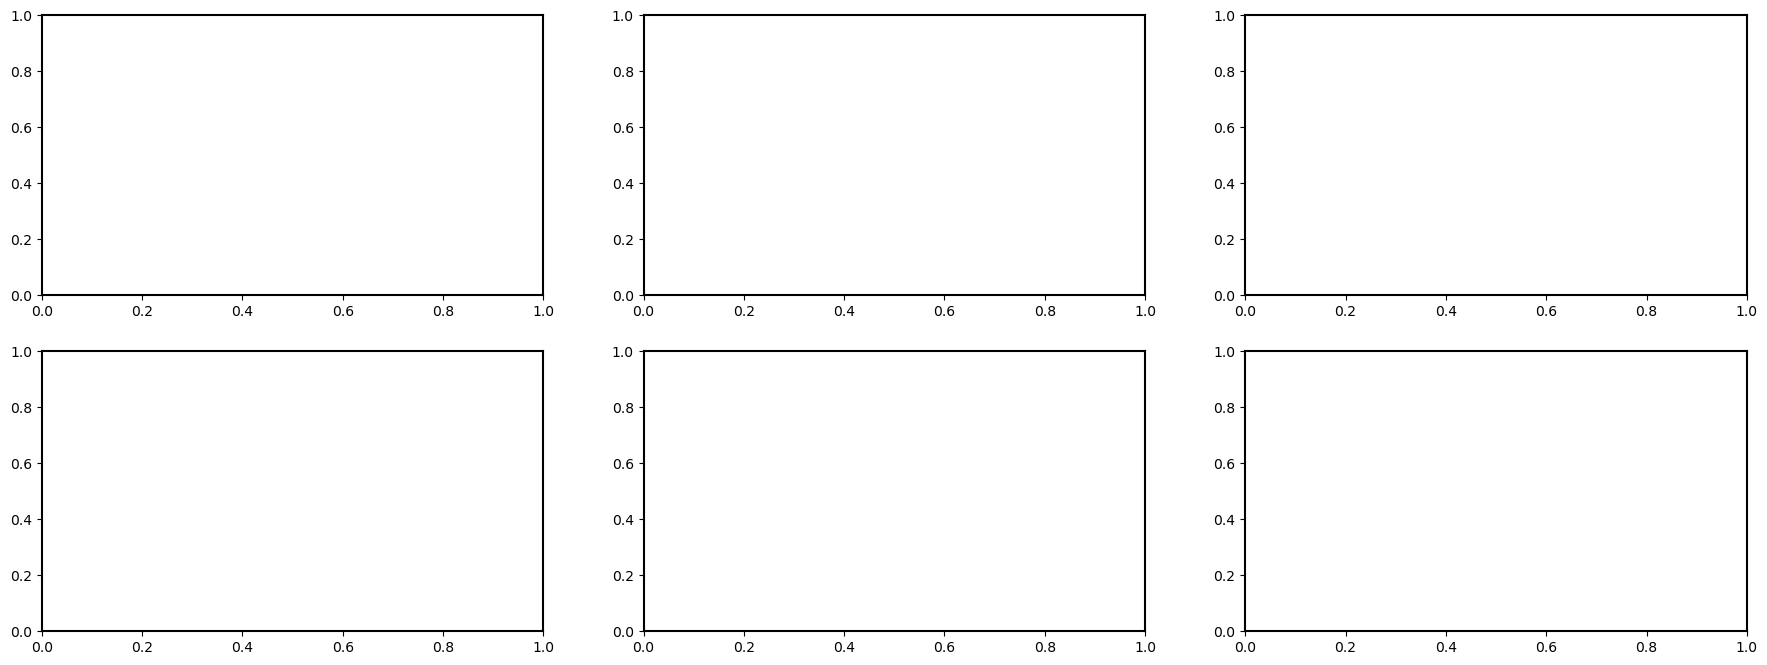

In [45]:
#ponderize average  of soil levels 

txt_x, txt_y = 0.0, 1.05

rmax, cmax = 2, 3
fig, ax = plt.subplots(nrows=rmax,ncols=cmax, figsize=(22,8),)

## Fig. a
rr, cc = 0, 0
y_outa1 = np.where(zna1>=np.sum(zna1) * 0.01, y_outa1, np.NaN)
x_outa1 = np.where(zna1>=np.sum(zna1) * 0.01, x_outa1, np.NaN)
z_outa1 = np.where(zna1>=np.sum(zna1) * 0.01, z_outa1, np.NaN)
ax[rr,cc].plot(x_outa1, y_outa1, c='k',                 linewidth=5.4)
ax[rr,cc].plot(x_outa1, y_outa1, c=plt.cm.RdBu([0.85]), linewidth=5)
ax[rr,cc].fill_between(x_outa1, y_outa1-z_outa1, y_outa1+z_outa1 ,alpha=0.3, color='C0', edgecolor='k')
ax[rr,cc].set_xlim(-0.2, 1.7)
ax[rr,cc].set_ylim(-1.5, 1)
ax[rr,cc].set_yticks(np.arange(-0.25,1.0+0.25,0.25))
ax[rr,cc].set_xlabel('SMI [-]', fontsize=15)
ax[rr,cc].set_ylabel('Corr(SMI,ET)', fontsize=15)
ax[rr,cc].yaxis.set_label_coords(-0.10,0.75)
ax[rr,cc].text(txt_x, txt_y, '(a)', transform=ax[rr,cc].transAxes, size=20, weight='bold')

y_outa2 = np.where(zna2>=np.sum(zna2) * 0.01, y_outa2, np.NaN)
x_outa2 = np.where(zna2>=np.sum(zna2) * 0.01, x_outa2, np.NaN)
z_outa2 = np.where(zna2>=np.sum(zna2) * 0.01, z_outa2, np.NaN)
ax[rr,cc].plot(x_outa2, y_outa2, c='k',                 linewidth=5.4)
ax[rr,cc].plot(x_outa2, y_outa2, c=plt.cm.RdBu([0.21]), linewidth=5)
ax[rr,cc].fill_between(x_outa2, y_outa2-z_outa2, y_outa2+z_outa2 ,alpha=0.3, facecolor='pink', edgecolor='k')

ax2 = ax[rr,cc].twinx()
xx_1 = x_outa1
yy_1 = zna1
yy_2 = yy_1[~np.isnan(xx_1)]
xx_2 = xx_1[~np.isnan(xx_1)]
xx = xx_2[~np.isnan(yy_2)]
yy = yy_2[~np.isnan(yy_2)]
ax2.bar(xx, yy/np.sum(zna1)*100., width=dxa, alpha=0.4, color='C0', edgecolor='k')

xx_1 = x_outa2
yy_1 = zna2
yy_2 = yy_1[~np.isnan(xx_1)]
xx_2 = xx_1[~np.isnan(xx_1)]
xx = xx_2[~np.isnan(yy_2)]
yy = yy_2[~np.isnan(yy_2)]
ax2.bar(xx, yy/np.sum(zna2)*100., width=dxa, alpha=0.4, color='pink', edgecolor='k')

ax2.set_ylim(0, 50)
ax2.set_yticks(np.arange(0,25+5,5))
ax2.set_ylabel('Percentage of data [%]', fontsize=13)
ax2.yaxis.set_label_coords(1.052,0.28)

ax[rr,cc].xaxis.set_tick_params(width=1.5, labelsize=13)
ax[rr,cc].yaxis.set_tick_params(width=1.5, labelsize=13)
ax2      .yaxis.set_tick_params(width=1.5, labelsize=13)

## Fig. b
rr, cc = 0, 1
y_outc1 = np.where(znc1>=np.sum(znc1) * 0.01, y_outc1, np.NaN)
x_outc1 = np.where(znc1>=np.sum(znc1) * 0.01, x_outc1, np.NaN)
z_outc1 = np.where(znc1>=np.sum(znc1) * 0.01, z_outc1, np.NaN)
ax[rr,cc].plot(x_outc1, y_outc1, c='k',                 linewidth=5.4)
ax[rr,cc].plot(x_outc1, y_outc1, c=plt.cm.RdBu([0.85]), linewidth=5)
ax[rr,cc].set_xlim(-0.2, 1.7)
ax[rr,cc].set_ylim(-0.75, 0.75)
ax[rr,cc].set_yticks(np.arange(-0.75,0.75+0.25,0.25))
ax[rr,cc].set_xlabel('SMI [-]', fontsize=15)
ax[rr,cc].set_ylabel('Correlation', fontsize=15)
ax[rr,cc].text(txt_x, txt_y, '(b)', transform=ax[rr,cc].transAxes, size=20, weight='bold')


y_outc2 = np.where(znc2>=np.sum(znc2) * 0.01, y_outc2, np.NaN)
x_outc2 = np.where(znc2>=np.sum(znc2) * 0.01, x_outc2, np.NaN)
z_outc2 = np.where(znc2>=np.sum(znc2) * 0.01, z_outc2, np.NaN)
ax[rr,cc].plot(x_outc2, y_outc2, c='k',                 linewidth=5.4)
ax[rr,cc].plot(x_outc2, y_outc2, c=plt.cm.RdBu([0.21]), linewidth=5)

r_outa2 = np.where(znc2>=np.sum(znc2) * 0.01, r_outc2, np.NaN)
ax[rr,cc].plot(x_outc2, r_outc2, c=plt.cm.RdBu([0.21]), linewidth=5, linestyle='--')
r_outc1 = np.where(znc1>=np.sum(znc1) * 0.01, r_outc1, np.NaN)
ax[rr,cc].plot(x_outc1, r_outc1, c=plt.cm.RdBu([0.85]), linewidth=5, linestyle='--')
ax[rr,cc].xaxis.set_tick_params(width=1.5, labelsize=13)
ax[rr,cc].yaxis.set_tick_params(width=1.5, labelsize=13)


## Fig. c
rr, cc = 1, 0
bin_len = np.arange(xmin, xmax+dx, dx).shape[0]
yval, xval = np.histogram(znb1, bins=np.arange(bin_len))
xval = np.diff(xval)/2.+xval[:-1]

x_msk1 = np.where(yval>=np.sum(yval) * 0.003, x_outb1, np.NaN )
ax[rr,cc].plot(x_msk1, y_outb1, c='k',linewidth=5.4)
ax[rr,cc].plot(x_msk1, y_outb1, c=plt.cm.RdBu([0.85]),linewidth=5)

ax[rr,cc].set_xlim(-0.0, 6)
ax[rr,cc].set_ylim(-0.0, 8)
ax[rr,cc].set_yticks(np.arange(0, 8+2, 2))
ax[rr,cc].set_xlabel('ET [mm day$^{-1}$]', fontsize=15)
ax[rr,cc].set_ylabel('P [mm day$^{-1}$]', fontsize=15)
ax[rr,cc].text(txt_x, txt_y, '(c)', transform=ax[rr,cc].transAxes, size=20, weight='bold')

xx_1 = x_msk1.flatten()
yy_1 = y_outb1.flatten()
yy_1 = np.where(xx_1,yy_1,np.NaN)
xx_1 = np.where(xx_1,xx_1,np.NaN)
yy_2 = yy_1[~np.isnan(xx_1)]
xx_2 = xx_1[~np.isnan(xx_1)]
xx = xx_2[~np.isnan(yy_2)]
yy = yy_2[~np.isnan(yy_2)]
slope, intercept, r, p, se = stats.linregress(xx, yy)
ax[rr,cc].plot(np.arange(-400,500), slope*np.arange(-400,500)+intercept, c=plt.cm.RdBu([0.85]), linestyle='--')



yval, xval = np.histogram(znb2, bins=np.arange(bin_len))
xval = np.diff(xval)/2.+xval[:-1]

x_msk2 = np.where(yval>=np.sum(yval) * 0.003, x_outb2, np.NaN )
ax[rr,cc].plot(x_msk2, y_outb2, c='k',linewidth=5.4)
ax[rr,cc].plot(x_msk2, y_outb2, c=plt.cm.RdBu([0.21]),linewidth=5)

xx_1 = x_msk2.flatten()
yy_1 = y_outb2.flatten()
yy_1 = np.where(xx_1,yy_1,np.NaN)
xx_1 = np.where(xx_1,xx_1,np.NaN)
yy_2 = yy_1[~np.isnan(xx_1)]
xx_2 = xx_1[~np.isnan(xx_1)]
xx = xx_2[~np.isnan(yy_2)]
yy = yy_2[~np.isnan(yy_2)]
slope, intercept, r, p, se = stats.linregress(xx, yy)
ax[rr,cc].plot(np.arange(-400,500), slope*np.arange(-400,500)+intercept, c=plt.cm.RdBu([0.21]), linestyle='--')

ax[rr,cc].xaxis.set_tick_params(width=1.5, labelsize=13)
ax[rr,cc].yaxis.set_tick_params(width=1.5, labelsize=13)

rr, cc = 0, 2
ax[rr, cc].set_visible(False)
rr, cc = 1, 1
ax[rr, cc].set_visible(False)
rr, cc = 1, 2
ax[rr, cc].set_visible(False)

matplotlib.rcParams['axes.linewidth'] = 1.5
plt.tight_layout()

In [ ]:
# calculate time serie of specific regions 

In [ ]:
# tigramite analysis to analysis feedback between PP, SM, EV

In [ ]:
# partial correlation analysis